# Machine Learning Models

In this project, 4 diferent machine learning models are going to be trained, tested and evaluated to see each one has  a better performance in predicting churn.
The choosen models are:
1. Logistic Regression
2. Random Forest 
3. XGBoost
4. Support Vector Machine (SVM)

The models will be evaluated using precision, recall, F1-score, and accuracy for both classes — with a focus on class 1 (churners), since missing a churner (false negative) is more costly than a false alarm.

Each model is trained in two phases: a baseline with default parameters, and a tuned version using RandomizedSearchCV optimised for F1. This allows a direct comparison of the gain from hyperparameter tuning.

To handle the class imbalance (~73% non-churn / ~27% churn), class_weight='balanced' is applied where available.

In order to establish the importance of the feature engineering step, the models will be trained and test with and without the new features.

## Without Feature Engineering

### Importe libraries and load dataset

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_data
from src.data.models import split_dataset, evaluate_model

df = load_data('../data/processed/telco_clean.csv')

X_train, X_test, y_train, y_test = split_dataset(df)

The processed dataset (telco_clean.csv) is loaded and split into 80% training / 20% test using stratified sampling to preserve the class distribution across both sets.

## Logistic Regression

## Random Forest

In [2]:
from src.models.random_forest import model_baseline, model_tuning

Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions. It is robust to overfitting and handles non-linear relationships well, making it a strong candidate for this type of tabular classification problem.

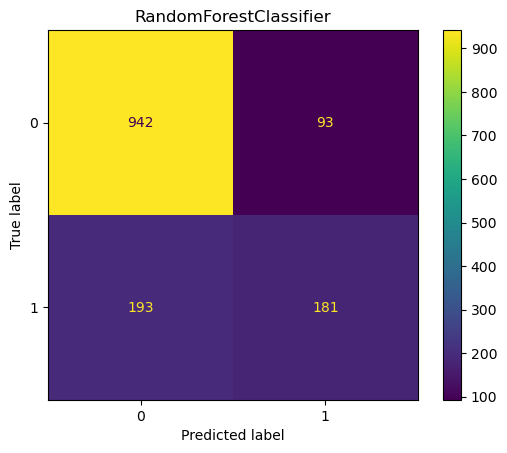

{'0': {'precision': 0.8299559471365638, 'recall': 0.9101449275362319, 'f1-score': 0.8682027649769585, 'support': 1035.0}, '1': {'precision': 0.6605839416058394, 'recall': 0.4839572192513369, 'f1-score': 0.558641975308642, 'support': 374.0}, 'accuracy': 0.7970191625266146, 'macro avg': {'precision': 0.7452699443712016, 'recall': 0.6970510733937844, 'f1-score': 0.7134223701428002, 'support': 1409.0}, 'weighted avg': {'precision': 0.7849984382164141, 'recall': 0.7970191625266146, 'f1-score': 0.786034038691685, 'support': 1409.0}}


In [3]:
baseline_model, report = model_baseline(X_train, X_test, y_train, y_test)

print(report)

The baseline Random Forest (default parameters, class_weight='balanced') achieves 78.8% overall accuracy, but this figure is misleading given the class imbalance (~73% non-churn / ~27% churn).

For the majority class (non-churners), performance is strong with an F1 of 0.86, which is expected as the model sees more examples of this class.

For the minority class (churners), performance is noticeably weaker — F1 of 0.56. Most critically, recall is only 0.52, meaning the model misses nearly half of all actual churners (false negatives). Since missing a churner is more costly than a false alarm in a business context, this is the key weakness of the baseline.

Despite class_weight='balanced' helping the model account for imbalance, the default hyperparameters are not sufficient to reliably identify churners. This motivates the tuning phase, which will optimise for F1 on class 1 using RandomizedSearchCV.

Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}


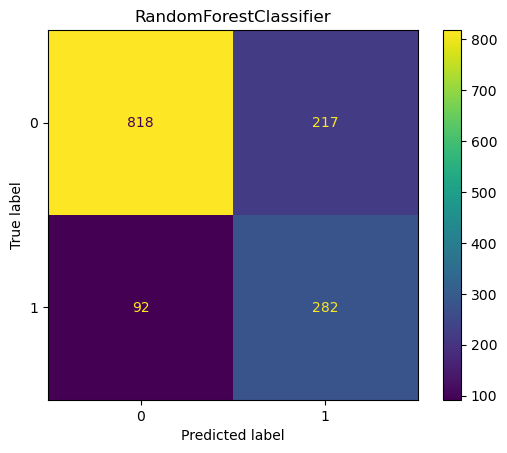

{'0': {'precision': 0.8989010989010989, 'recall': 0.7903381642512077, 'f1-score': 0.8411311053984576, 'support': 1035.0}, '1': {'precision': 0.5651302605210421, 'recall': 0.7540106951871658, 'f1-score': 0.6460481099656358, 'support': 374.0}, 'accuracy': 0.7806955287437899, 'macro avg': {'precision': 0.7320156797110705, 'recall': 0.7721744297191868, 'f1-score': 0.7435896076820467, 'support': 1409.0}, 'weighted avg': {'precision': 0.8103061425106508, 'recall': 0.7806955287437899, 'f1-score': 0.7893489618272188, 'support': 1409.0}}


In [4]:
best_model, report = model_tuning(X_train, X_test, y_train, y_test)

print(report)

The tuned model (RandomizedSearchCV with scoring='f1', cv=5, n_iter=50) finds the best configuration to be max_depth=10, bootstrap=False, with regularised leaf constraints (min_samples_leaf=2, min_samples_split=10).

The key gain is in recall for churners: 0.484 → 0.754 — the model now correctly identifies 75% of actual churners, up from 48% in the baseline. This directly reduces the most costly error in a churn setting (missing a customer about to leave).

This comes at a trade-off: precision drops from 0.661 → 0.565 (more false alarms), and overall accuracy dips slightly from 0.797 → 0.781. However, given that missing a churner is more costly than a false positive, this is an acceptable and deliberate trade-off — reflected in the F1 improvement from 0.559 → 0.646.

The max_depth=10 constraint and leaf regularisation prevent the trees from memorising the training data, helping generalise better to the test set on the minority class.

## XGBoost

## Support Vector Machine